In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## use gradient boosted trees, SVM, dense nets or whatever else. Can either take m minutes to classify whether eruption happens in n minutes in future, or regress on integrated eruption value. Can also use m minutes to predict next minute and iterate to predict all data and eruption curve into the future, use to generate. train, val, test split and play with multiple approaches in order to have a sense of what's good. 

In [42]:
data = pd.read_csv("processed_data/dataInterpolated.csv")

In [43]:
use_data = data[['Unnamed: 0', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM',
       'VPRS_LFE', 'VPRS_LFN', 'VPRS_LFZ', 'VPPC_LFE', 'VPPC_LFN', 'VPPC_LFZ',
       'VPNC_LFE', 'VPNC_LFN', 'VPNC_LFZ', 'CO2_ppm','lake_size', 'Eruption_Activity']]

In [44]:
dates = use_data['Unnamed: 0'].to_numpy()

In [45]:
dates[100][:-6]

'2024-01-31 01:40:00'

In [46]:
dates = [datetime.strptime(i[:-6],'%Y-%m-%d %H:%M:%S') for i in dates]

In [47]:
dates[:5]

[datetime.datetime(2024, 1, 31, 0, 0),
 datetime.datetime(2024, 1, 31, 0, 1),
 datetime.datetime(2024, 1, 31, 0, 2),
 datetime.datetime(2024, 1, 31, 0, 3),
 datetime.datetime(2024, 1, 31, 0, 4)]

In [48]:
(dates[1]-dates[0]).total_seconds()

60.0

In [49]:
times = np.zeros_like(dates)[:-1]
for i in range(len(dates) - 1):
    times[i] = (dates[i+1]-dates[i]).total_seconds()


In [50]:
print(np.min(times), np.max(times)) #so all values are evenly spaced by a minute

60.0 60.0


In [51]:
#making features and labels
full_data_arr = use_data.to_numpy()

In [52]:
full_data_arr.shape

(964801, 17)

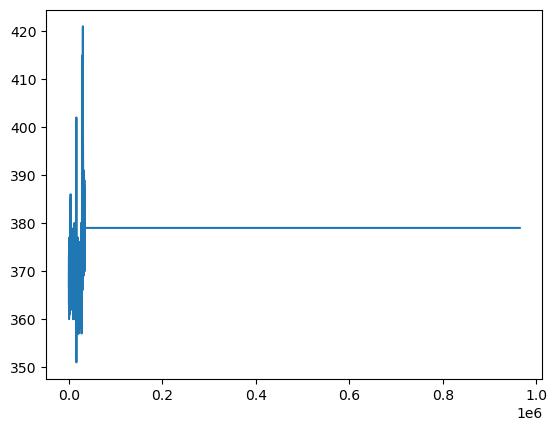

In [53]:
plt.plot(full_data_arr[:,-7])